# SII：实测输入、独立物理验证与重建稳定性

本Notebook是可执行的计算证据。物理因果链见 [原理说明](../docs/SII_PHYSICS_ZH.md)，
函数、数据结构和复现方法见 [代码实现说明](../docs/SII_IMPLEMENTATION_ZH.md)。
缺失的电子学参数为0并关闭；实测SPE、电荷涨落和光追时间响应仍然保留。
所有天体均为给定亮度的静态场景；含遮挡的圆盘不代表正在运动的真实凌星。


In [1]:
from pathlib import Path
import os, sys, json, platform, hashlib
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from dataclasses import replace
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT/'python').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'python'))
import sii_unified as sii
import sii_reconstruction as reco
from sii_validation import (verify_main_parameters, analytic_waveform_calibration,
    thermal_mode_counts, waveform_records, standard_deviation_interval, proportion_interval,
    profile_model_grid, profile_grid_interval)
FIG = ROOT/'docs/sii_science_figures'
OUT = ROOT/'validation/sii_science'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260905
plt.rcParams.update({'figure.dpi':110, 'savefig.dpi':180, 'axes.grid':True, 'grid.alpha':.2})
summary = {'seed':SEED, 'python':platform.python_version(), 'numpy':np.__version__, 'scipy':scipy.__version__}
summary['code_sha256_lf']={path:hashlib.sha256((ROOT/path).read_bytes().replace(b'\r\n',b'\n')).hexdigest()
    for path in ['python/sii_unified.py','python/sii_reconstruction.py','python/sii_validation.py',
                 'python/sii_observation.py','tools/validate_sii_observation.py',
                 'tools/build_sii_science_notebook.py']}
manifest = verify_main_parameters(ROOT)
summary['main_parameter_commit'] = manifest['main_commit']
instrument = sii.Instrument.from_repository(ROOT)
observation = sii.Observation(hours_per_night=6., segment_s=1200, visibility_subsamples_per_segment=9)
layout = pd.read_csv(ROOT/'configs/arrays/layout_0803_reco32_coordinates.csv')
summary['derived_input_sha256_lf']={path:hashlib.sha256((ROOT/path).read_bytes().replace(b'\r\n',b'\n')).hexdigest()
    for path in ['configs/arrays/layout_0803_reco32_coordinates.csv',
                 'configs/optics/lact2_measured_single_pixel_400nm.csv',
                 'configs/optics/lact2_measured_single_pixel_400nm.provenance.json']}
unknown = ['microcell_recovery_time_ns','intrinsic_time_jitter_ns','electronic_noise_rms_mv',
           'sipm_crosstalk_probability','sipm_afterpulse_probability','dark_count_rate_hz','adc_bits']
assert all(getattr(instrument, name) == 0 for name in unknown)
summary['missing_effects_disabled'] = {name:getattr(instrument,name) for name in unknown}
display(pd.DataFrame(manifest['files'])[['path','matches_main']])

,path,matches_main
0,configs/electronics/measured_spe_4ns.cfg,True
1,configs/electronics/parameters/spe_template_me...,True
2,configs/electronics/parameters/spe_charge_samp...,True
3,configs/electronics/devices/s17351_tiled_2x4.cfg,True
4,configs/efficiency/mirror_reflectivity_dm0113_...,True
5,configs/efficiency/filter_transmission.csv,True
6,configs/efficiency/sipm_pde.csv,True
7,configs/nsb/nsb_spectrum.csv,True
8,configs/calibrated/lact2_measured_20260622/mir...,True
9,configs/calibrated/lact2_measured_20260622/mir...,True


## 1. 哪些输入是实测，哪些是推导或场景假设

第一幅图是读取的SPE响应和光追时间核。SPE的长尾已经包含在波形卷积中，
不能据此再设置一个相同时间常数的微单元恢复过程。2 nm矩形SII通带和固定大气透过率是场景假设。


,parameter,value,unit,source
0,SPE integral,84.034956,mV ns,measured
1,charge second moment,1.032545,1,measured samples
2,optical time RMS,0.548827,ns,ray trace
3,sample interval,4.000000,ns,main config
4,"stellar rate, m_AB=2",199.889298,MHz,spectrum + response
5,NSB rate,0.573214,MHz,sky model + passband
6,coherence area,0.133429,ps,same passband
7,SII passband width,2.000000,nm,scenario


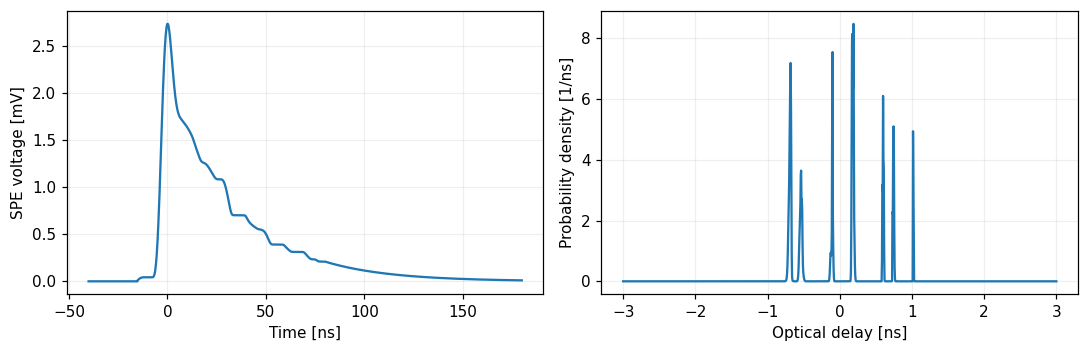

In [2]:
spe_t, spe_v = sii.load_measured_spe_template(instrument.spe_template_path)
charge = sii.load_empirical_charge_factors(instrument.charge_samples_path)
timing = sii.load_optical_timing_mixture(instrument.optical_timing_kernel_path)
star = sii.detected_star_rate_hz(2., instrument)
parameters = pd.DataFrame([
    ['SPE integral',np.trapezoid(spe_v,spe_t),'mV ns','measured'],
    ['charge second moment',np.mean(charge**2),'1','measured samples'],
    ['optical time RMS',timing['rms_spread_ns'],'ns','ray trace'],
    ['sample interval',instrument.sample_width_ns,'ns','main config'],
    ['stellar rate, m_AB=2',star/1e6,'MHz','spectrum + response'],
    ['NSB rate',instrument.detected_nsb_rate_hz/1e6,'MHz','sky model + passband'],
    ['coherence area',instrument.coherence_area_s*1e12,'ps','same passband'],
    ['SII passband width',instrument.optical_width_nm,'nm','scenario'],
], columns=['parameter','value','unit','source'])
parameters.to_csv(OUT/'parameters.csv',index=False)
summary['parameters'] = parameters.to_dict(orient='records')
display(parameters)
time = np.linspace(-3,3,1201)
density = sum(w*np.exp(-.5*((time-m)/s)**2)/(np.sqrt(2*np.pi)*s)
              for w,m,s in zip(timing['weights'],timing['mean_delay_ns'],timing['std_delay_ns']) if s>0)
fig, axes = plt.subplots(1,2,figsize=(10,3.3))
axes[0].plot(spe_t,spe_v); axes[0].set(xlabel='Time [ns]',ylabel='SPE voltage [mV]')
axes[1].plot(time,density); axes[1].set(xlabel='Optical delay [ns]',ylabel='Probability density [1/ns]')
fig.tight_layout(); fig.savefig(FIG/'01_inputs.png'); plt.show()

## 2. 用另一种物理生成方法检查HBT关系

以下计算从相关复高斯热光模开始，再做条件泊松探测。它不调用共享光电子对生成器。
这里每条记录包含16个独立模，用于检验Siegert关系和热光超泊松方差；不是LACT的实际相干模数。


In [3]:
counts, intensity = thermal_mode_counts(np.random.default_rng(SEED), 300000, 6., 2., .6)
thermal = pd.DataFrame([
    ['mean intensity',1.,intensity[:,0].mean()],
    ['intensity covariance',.6/16,np.cov(intensity.T)[0,1]],
    ['mean detected count',8.,counts[:,0].mean()],
    ['count variance',8.+36/16,counts[:,0].var(ddof=1)],
    ['count covariance',36*.6/16,np.cov(counts.T)[0,1]],
],columns=['quantity','theory','simulation'])
thermal['relative_difference'] = thermal.simulation/thermal.theory-1
assert np.max(abs(thermal.relative_difference)) < .04
thermal.to_csv(OUT/'thermal_modes.csv',index=False)
summary['thermal_modes'] = thermal.to_dict(orient='records')
display(thermal)

,quantity,theory,simulation,relative_difference
0,mean intensity,1.0000,1.000313,0.000313
1,intensity covariance,0.0375,0.037525,0.000655
2,mean detected count,8.0000,7.997673,-0.000291
3,count variance,10.2500,10.268915,0.001845
4,count covariance,1.3500,1.329592,-0.015117


## 3. 波形标定与独立解析响应

Monte Carlo将记录分为训练、选择、尺度估计和最终响应检验部分。
解析对照由连续SPE自相关、光学时间核和Bartlett协方差计算，不用Monte Carlo的峰形作为输入。
图中的曲线都是单位平方可见度的期望响应，不是单次物理波形中可见的相关峰。


,sigma_1200_s,analytic_sigma_1200_s,response_relative_uncertainty,sigma_relative_uncertainty,selected_shrinkage,fine_grid_sigma_ratio,photon_degeneracy
0,0.079267,0.075453,0.006407,0.031281,0.0001,1.0,0.000027


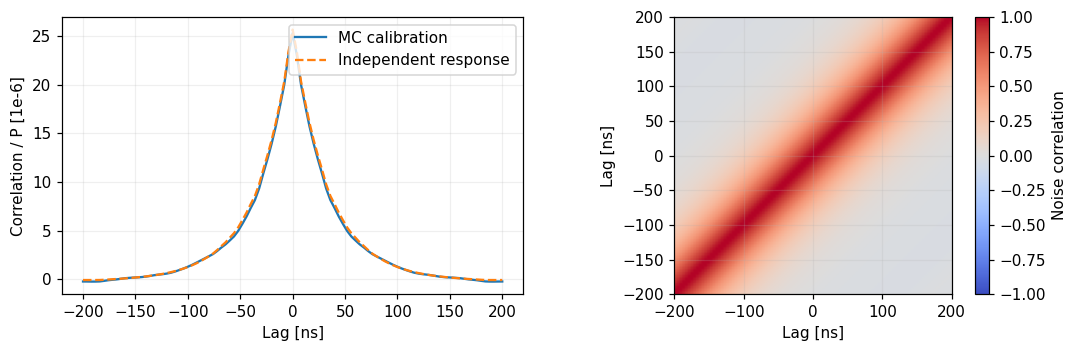

In [4]:
calibration, calibration_diagnostics = sii.simulate_waveform_gls_calibration(
    instrument, null_records=2048, signal_records=512, covariance_shrinkage='auto', seed=SEED)
analytic, analytic_diagnostics = analytic_waveform_calibration(instrument)
analytic_fine, _ = analytic_waveform_calibration(instrument, fine_dt_ns=.025)
sigma_mc = sii.waveform_gls_weights(calibration,1200)[1]
sigma_analytic = sii.waveform_gls_weights(analytic,1200)[1]
summary['calibration'] = {'sigma_1200_s':sigma_mc,'analytic_sigma_1200_s':sigma_analytic,
    'response_relative_uncertainty':calibration.response_relative_uncertainty,
    'sigma_relative_uncertainty':calibration.sigma_relative_uncertainty,
    'selected_shrinkage':calibration.covariance_shrinkage,
    'fine_grid_sigma_ratio':sii.waveform_gls_weights(analytic_fine,1200)[1]/sigma_analytic,
    'photon_degeneracy':analytic_diagnostics['photon_degeneracy']}
np.savez_compressed(OUT/'waveform_calibration.npz',**vars(calibration))
assert abs(summary['calibration']['fine_grid_sigma_ratio']-1)<.01
pd.DataFrame({'lag_ns':calibration.lags_ns,'mc_peak':calibration.peak_per_visibility2,
              'analytic_peak':analytic.peak_per_visibility2}).to_csv(OUT/'response.csv',index=False)
pd.DataFrame(calibration.covariance_per_block).to_csv(OUT/'covariance.csv',index=False)
display(pd.DataFrame([summary['calibration']]))
fig, axes = plt.subplots(1,2,figsize=(10,3.3))
axes[0].plot(calibration.lags_ns,calibration.peak_per_visibility2*1e6,label='MC calibration')
axes[0].plot(analytic.lags_ns,analytic.peak_per_visibility2*1e6,'--',label='Independent response')
axes[0].set(xlabel='Lag [ns]',ylabel='Correlation / P [1e-6]'); axes[0].legend()
corr = calibration.covariance_per_block/np.sqrt(np.outer(np.diag(calibration.covariance_per_block),np.diag(calibration.covariance_per_block)))
im=axes[1].imshow(corr,origin='lower',extent=[-200,200,-200,200],vmin=-1,vmax=1,cmap='coolwarm')
axes[1].set(xlabel='Lag [ns]',ylabel='Lag [ns]'); fig.colorbar(im,ax=axes[1],label='Noise correlation')
fig.tight_layout();fig.savefig(FIG/'02_gls_response.png');plt.show()

## 4. 独立样本、注入倍数与积分时长

这些样本不参与标定，也不重新调节权重。标准差区间来自有限样本的卡方区间。
放大注入只用于验证响应斜率；实际场景的HBT对率仍按物理值计算。
不同块长检验的是实际短波形统计，不是直接画预设的T的负二分之一次方曲线。


,kind,batch,estimator,mean_over_sigma,std_over_sigma,std_ci_low,std_ci_high
0,null,0,MC,0.0584,1.0234,0.9643,1.0902
1,null,0,analytic,0.0403,1.0184,0.9596,1.0849
2,null,1,MC,-0.0080,1.0589,0.9978,1.1281
3,null,1,analytic,0.0198,1.0574,0.9963,1.1264
4,null,2,MC,0.0687,0.9845,0.9277,1.0489
5,null,2,analytic,0.0489,0.9625,0.9070,1.0254


,scale,estimator,response,sem
0,1000.0,MC,1.01305,0.04481
1,1000.0,analytic,0.97831,0.04190
2,3000.0,MC,0.99519,0.01670
3,3000.0,analytic,0.99574,0.01495
4,10000.0,MC,1.00634,0.00510
5,10000.0,analytic,1.00163,0.00493


,duration_us,std_over_sigma,ci_low,ci_high
0,10.0,1.082296,0.995962,1.185146
1,40.0,0.993427,0.914182,1.087832


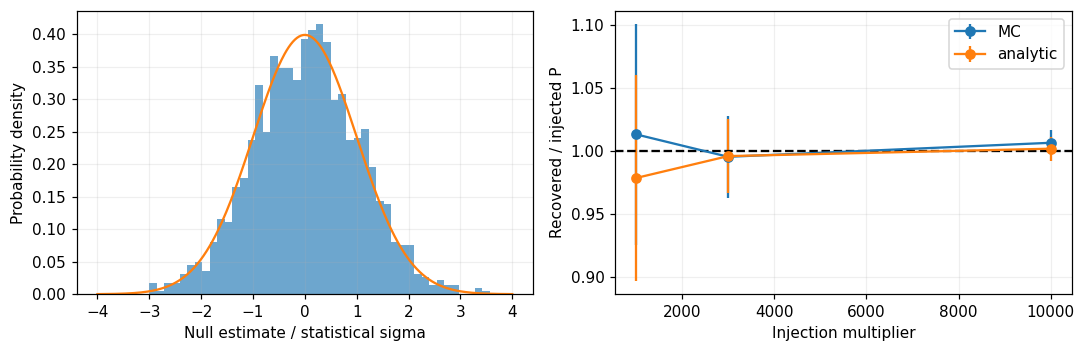

In [5]:
validation_rows=[]
independent_null=[]
for batch in range(3):
    _, records=waveform_records(instrument,512,SEED+100+batch)
    independent_null.append(records)
    for name,cal in [('MC',calibration),('analytic',analytic)]:
        values,sigma=sii.estimate_visibility2_gls(records,cal)
        ci=standard_deviation_interval(values)/sigma
        validation_rows.append({'kind':'null','batch':batch,'estimator':name,
            'mean_over_sigma':float(values.mean()/sigma),'std_over_sigma':float(values.std(ddof=1)/sigma),
            'std_ci_low':ci[0],'std_ci_high':ci[1]})
validation_table=pd.DataFrame(validation_rows)
validation_table.to_csv(OUT/'independent_null.csv',index=False)
display(validation_table.round(4))
scale_rows=[]
for index,scale in enumerate([1000.,3000.,10000.]):
    _,records=waveform_records(instrument,192,SEED+200+index,visibility2=1.,pair_scale=scale)
    for name,cal in [('MC',calibration),('analytic',analytic)]:
        values,_=sii.estimate_visibility2_gls(records,cal)
        scale_rows.append({'scale':scale,'estimator':name,'response':float(values.mean()/scale),
                           'sem':float(values.std(ddof=1)/np.sqrt(len(values))/scale)})
scale_table=pd.DataFrame(scale_rows)
scale_table.to_csv(OUT/'injection_scale.csv',index=False)
display(scale_table.round(5))
duration_rows=[]
for index,duration in enumerate([10000.,40000.]):
    _,records=waveform_records(instrument,256,SEED+300+index,duration_ns=duration)
    values,sigma=sii.estimate_visibility2_gls(records,calibration,exposure_s=duration*1e-9)
    ci=standard_deviation_interval(values)/sigma
    duration_rows.append({'duration_us':duration/1000,'std_over_sigma':values.std(ddof=1)/sigma,
                          'ci_low':ci[0],'ci_high':ci[1]})
duration_table=pd.DataFrame(duration_rows)
duration_table.to_csv(OUT/'block_duration.csv',index=False)
summary['independent_null']=validation_table.to_dict(orient='records')
summary['injection_scales']=scale_table.to_dict(orient='records')
summary['block_durations']=duration_table.to_dict(orient='records')
display(duration_table)
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
values,sigma=sii.estimate_visibility2_gls(np.concatenate(independent_null),calibration)
axes[0].hist(values/sigma,bins=45,density=True,alpha=.65)
x=np.linspace(-4,4,400);axes[0].plot(x,np.exp(-x*x/2)/np.sqrt(2*np.pi))
axes[0].set(xlabel='Null estimate / statistical sigma',ylabel='Probability density')
for label,g in scale_table.groupby('estimator'):
    axes[1].errorbar(g.scale,g.response,yerr=1.96*g['sem'],fmt='o-',label=label)
axes[1].axhline(1.,color='k',ls='--');axes[1].set(xlabel='Injection multiplier',ylabel='Recovered / injected P')
axes[1].legend();fig.tight_layout();fig.savefig(FIG/'03_independent_checks.png');plt.show()

### 4.1 三镜共同波形、插值收敛与较长记录

本节实际重新运行联合观测入口，不读取上次保存的结果来代替计算。
同一台望远镜的ADC由所有相关基线共享。先检验注入后的时延补偿、独立留出和零信号，
再让16至512点半宽使用同一批光子和相同时间区间，检查响应与噪声变化。
512点是数值参考，不代表连续模拟真值；误差棒利用同记录的配对差，保留方法间相关性。
另用独立生成的96 μs物理倍率记录对照24 μs记录的曝光缩放。

下方图表由本节执行生成。三镜弱对过程与独立热光模基准各有适用范围，
较长记录检验仍局限于微秒级，不足以证明整夜状态平稳。


calibration: 128/256
calibration: 256/256
injection_holdout: 128/384
injection_holdout: 256/384
injection_holdout: 384/384
physical_scale: 128/384
physical_scale: 256/384
physical_scale: 384/384
null: 128/384
null: 256/384
null: 384/384
long_physical_scale: 128/384
long_physical_scale: 256/384
long_physical_scale: 384/384
{
  "checks": [
    {
      "name": "independent_injection_response",
      "max_abs_z": 1.8475657740323344,
      "passed": true
    },
    {
      "name": "independent_null_mean",
      "max_abs_z": 1.1569745745547209,
      "passed": true
    },
    {
      "name": "whole_record_vs_four_blocks",
      "max_abs_z": 1.4411214000597132,
      "passed": true
    },
    {
      "name": "independent_thermal_moments",
      "max_abs_z": 1.441621425541838,
      "passed": true
    },
    {
      "name": "independent_long_record_noise_scaling",
      "min_scaled_sigma_ratio": 0.9762782783941627,
      "max_scaled_sigma_ratio": 1.041397149380248,
      "passed": true
    }
 

,name,max_abs_z,passed,min_scaled_sigma_ratio,max_scaled_sigma_ratio
0,independent_injection_response,1.847566,True,NaN,NaN
1,independent_null_mean,1.156975,True,NaN,NaN
2,whole_record_vs_four_blocks,1.441121,True,NaN,NaN
3,independent_thermal_moments,1.441621,True,NaN,NaN
4,independent_long_record_noise_scaling,NaN,True,0.976278,1.041397


,half_width,baseline,common_duration_s,reference_half_width,response,response_sem,response_minus_reference,paired_sem,noise_std_ratio_to_reference
0,16,0-1,0.000019,512,0.947545,0.006664,-0.000216,0.000609,0.987014
1,16,0-2,0.000019,512,0.935990,0.012146,0.000094,0.001433,0.996424
2,16,1-2,0.000019,512,0.960787,0.009542,-0.023321,0.001042,0.979741
3,32,0-1,0.000019,512,0.947413,0.006694,-0.000348,0.000419,0.992544
4,32,0-2,0.000019,512,0.935816,0.012278,-0.000080,0.000966,1.003264
5,32,1-2,0.000019,512,0.972670,0.009645,-0.011439,0.000712,0.990216
6,64,0-1,0.000019,512,0.947458,0.006716,-0.000303,0.000275,0.996329
7,64,0-2,0.000019,512,0.935769,0.012350,-0.000127,0.000604,1.004033
8,64,1-2,0.000019,512,0.979161,0.009693,-0.004947,0.000479,0.995203
9,128,0-1,0.000019,512,0.947521,0.006715,-0.000239,0.000166,0.998616


,baseline,short_exposure_s,long_exposure_s,scaled_sigma_ratio,low_95,high_95
0,0-1,0.000023,0.000095,1.041397,0.942014,1.151266
1,0-2,0.000023,0.000095,1.013768,0.917022,1.120722
2,1-2,0.000023,0.000095,0.976278,0.883109,1.079277


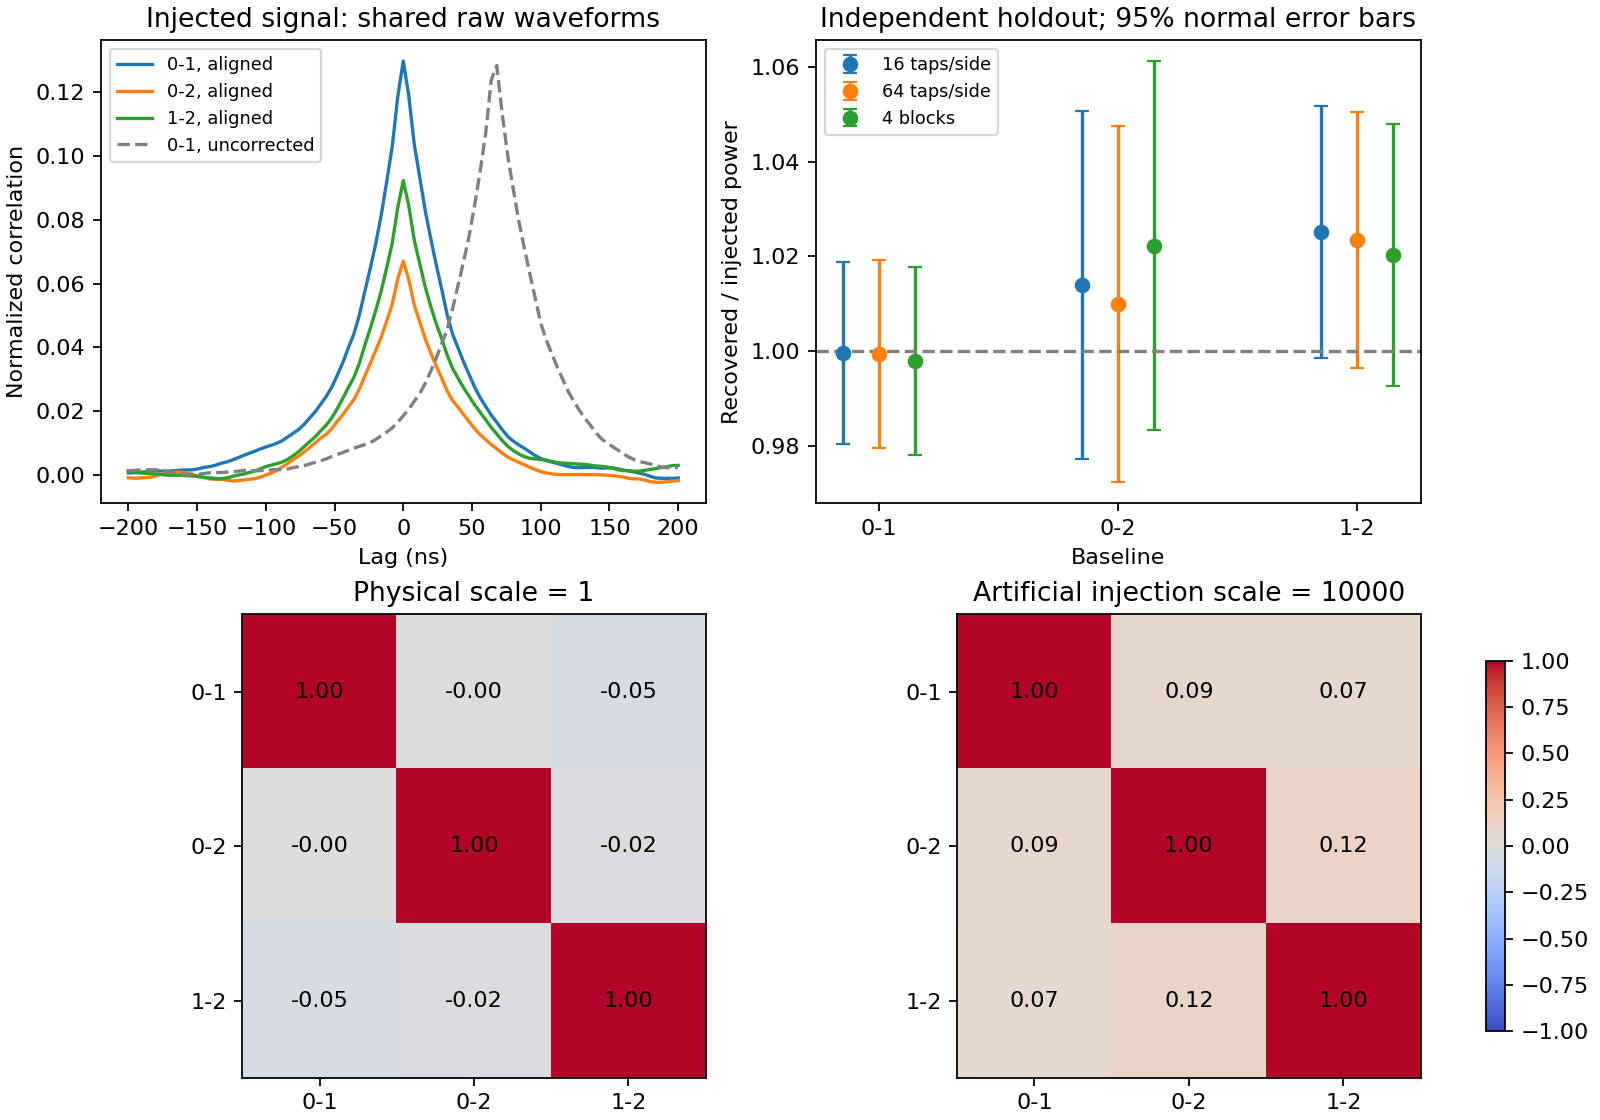

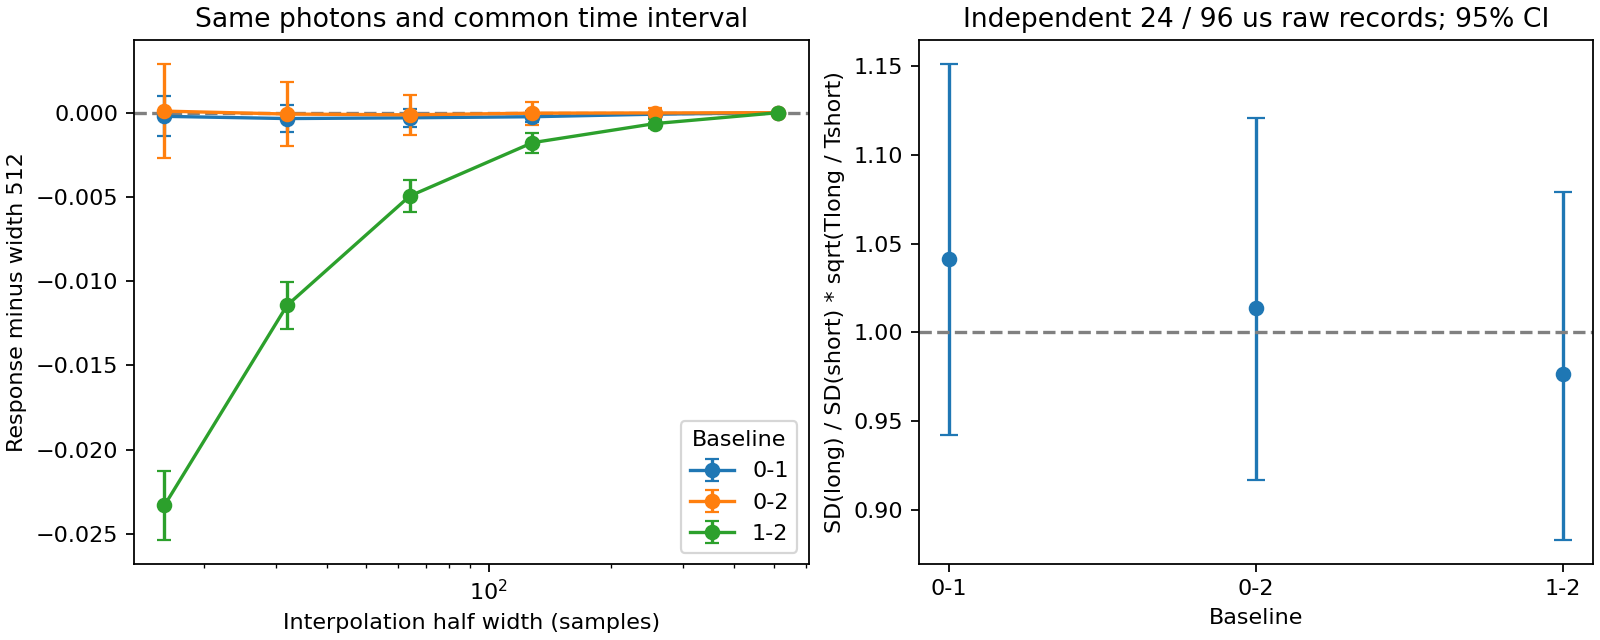

In [6]:
import subprocess
from IPython.display import Image
completed = subprocess.run([sys.executable, '-X', 'utf8', str(ROOT/'tools/validate_sii_observation.py')],
                           cwd=ROOT, capture_output=True, text=True, encoding='utf-8')
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()
JOINT = ROOT/'validation/sii_observation'
joint_summary = json.loads((JOINT/'summary.json').read_text(encoding='utf-8'))
assert all(item['passed'] for item in joint_summary['checks'])
summary['joint_observation'] = {
    'execution': 'fresh waveform simulation executed by this notebook',
    'summary_sha256_lf': hashlib.sha256((JOINT/'summary.json').read_bytes().replace(b'\r\n',b'\n')).hexdigest(),
    'short_records': joint_summary['calibration_records']+3*joint_summary['records'],
    'long_records': joint_summary['long_records'],
    'checks': joint_summary['checks'],
    'hour_scale_inference_uses_joint_covariance': False}
display(pd.DataFrame(joint_summary['checks']))
display(pd.read_csv(JOINT/'kernel_convergence.csv'))
display(pd.read_csv(JOINT/'exposure_scaling.csv'))
display(Image(filename=str(JOINT/'observation_validation.png')))
display(Image(filename=str(JOINT/'processing_convergence.png')))

## 5. 32台望远镜的时间与光谱平均测量

下面实际生成32台望远镜、6小时、每段20分钟的8928个UV测量。
每段同时平均时间变化和通带内的平方可见度。右图显示带噪声测量，允许出现负值；
颜色范围仅用于显示，不对拟合输入作裁剪。同一次标定误差在所有测量间共享。
本节采用双镜波形标定的长曝光统计分支；第4.1节的三镜联合实验并未自动替换
本节的32镜协方差或完成整夜时变处理。两者通过明确的验证范围关联。


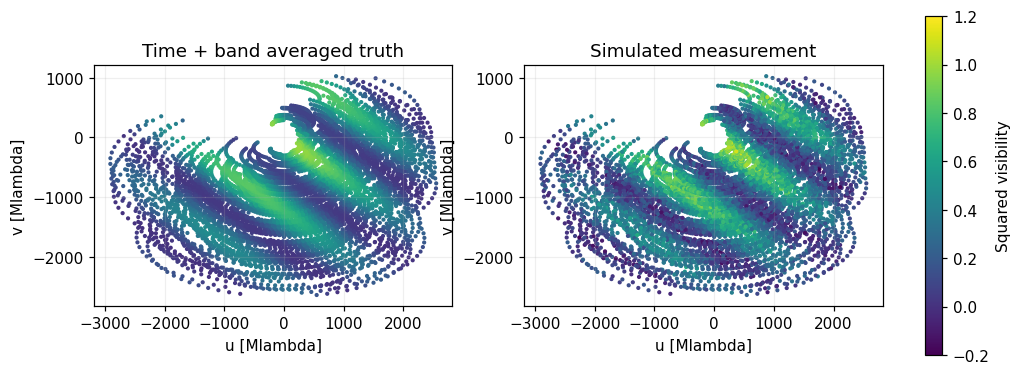

,telescopes,uv_measurements,hours,integration_s_per_measurement,time_subsamples,spectral_nodes,max_baseline_m,expected_hbt_pairs_per_20us
0,32,8928,6,1200,9,5,1219.209627,0.106625


In [7]:
source_cases={'binary':sii.BinarySource(),'single_disk':sii.BinarySource(primary_diameter_mas=.16),
              'ellipse':sii.EllipseSource(),'transit':sii.TransitSource()}
pipelines={}
for index,(case,source) in enumerate(source_cases.items()):
    pipelines[case]=sii.run_sii_pipeline(layout,source,observation,instrument,
        seed=SEED+400+index,source_case=case,estimator='waveform_gls',
        waveform_calibration=calibration,do_reconstruction=False)
frame=pipelines['binary'].measurements
assert len(frame)==32*31//2*18
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,column,title in zip(axes,['visibility2_true','visibility2_measured'],['Time + band averaged truth','Simulated measurement']):
    im=ax.scatter(frame.u_lambda/1e6,frame.v_lambda/1e6,c=frame[column],s=3,cmap='viridis',vmin=-.2,vmax=1.2)
    ax.set(xlabel='u [Mlambda]',ylabel='v [Mlambda]',title=title);ax.set_aspect('equal')
fig.colorbar(im,ax=axes,label='Squared visibility',fraction=.025)
fig.savefig(FIG/'04_uv_measurements.png',bbox_inches='tight');plt.show()
frame.drop(columns=['uv_samples_u','uv_samples_v','uv_samples_weight']).to_csv(OUT/'binary_measurements.csv',index=False)
summary['observation']={'telescopes':len(layout),'uv_measurements':len(frame),'hours':6,
    'integration_s_per_measurement':1200,'time_subsamples':9,'spectral_nodes':5,
    'max_baseline_m':float(frame.baseline_m.max()),
    'expected_hbt_pairs_per_20us':star**2*instrument.coherence_area_s*20e-6}
display(pd.DataFrame([summary['observation']]))

## 6. 参数区间是否具有预期覆盖率

在预先指定的均匀圆盘模型中，只拟合角直径和共享标定增益。
区间由剖面似然构造，1000次独立测量实现检查95%区间覆盖率。
这验证的是给定模型和条件噪声尺度下的参数推断，不证明天体一定是均匀圆盘，
也不把参数区间当作非参数图像的像素区间。另列噪声尺度标定误差的敏感性。


,estimate,low,high,touches_boundary,disconnected
0,0.1604,0.159656,0.161241,False,False


,assumed_sigma_scale,covered,trials,coverage,binomial_ci_low,binomial_ci_high,boundary_intervals,disconnected_intervals
0,1.00000,953,1000,0.953,0.937987,0.965265,0,0
1,0.93869,939,1000,0.939,0.922329,0.953022,0,0
2,1.06131,963,1000,0.963,0.949359,0.973817,0,0


,source,time_nodes,reference_time_nodes,max_abs_P_difference,rms_difference_over_row_sigma
0,binary,9,27,0.000074,0.000140
1,single_disk,9,27,0.000006,0.000014
2,ellipse,9,27,0.000010,0.000016
3,transit,9,27,0.000005,0.000009


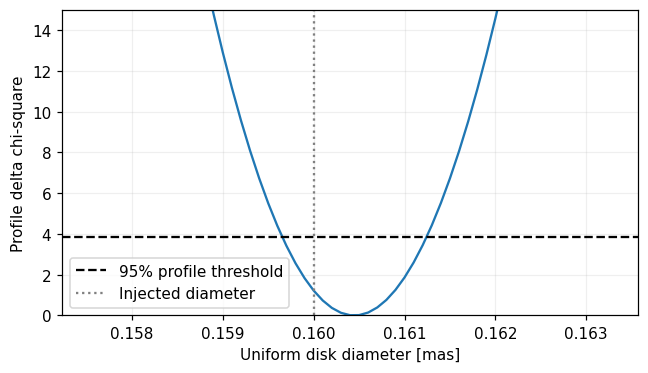

In [8]:
parameter_uv=sii.prepare_reconstruction_uv(pipelines['single_disk'].measurements,cell_mlambda=120.)
sample_u,sample_v,group,fraction=parameter_uv.sampling
radius=np.hypot(sample_u,sample_v)
diameter_grid=np.linspace(.12,.20,801)
models=np.array([np.bincount(group,weights=fraction*sii.uniform_disk_visibility(radius,diameter)**2,
                            minlength=len(parameter_uv.u_lambda)) for diameter in diameter_grid])
statistic,_=profile_model_grid(parameter_uv,models)
interval=profile_grid_interval(diameter_grid,statistic[0])
summary['diameter_interval']=interval
pd.DataFrame({'diameter_mas':diameter_grid,'delta_chi2':statistic[0]-statistic[0].min()}).to_csv(OUT/'diameter_profile.csv',index=False)
rng=np.random.default_rng(SEED+900)
model_true=models[400]
realizations=(1+rng.normal(0,parameter_uv.calibration_relative_sigma,(1000,1)))*model_true
realizations+=rng.normal(0,parameter_uv.sigma,(1000,len(model_true)))
coverage_rows=[]
for scale in [1.,1-1.96*calibration.sigma_relative_uncertainty,1+1.96*calibration.sigma_relative_uncertainty]:
    scaled=replace(parameter_uv,sigma=parameter_uv.sigma*scale)
    statistics,_=profile_model_grid(scaled,models,realizations)
    intervals=[profile_grid_interval(diameter_grid,row) for row in statistics]
    covered=sum(row['low']<=.16<=row['high'] for row in intervals)
    lower,upper=proportion_interval(covered,len(intervals))
    coverage_rows.append({'assumed_sigma_scale':scale,'covered':covered,'trials':len(intervals),
        'coverage':covered/len(intervals),'binomial_ci_low':lower,'binomial_ci_high':upper,
        'boundary_intervals':sum(row['touches_boundary'] for row in intervals),
        'disconnected_intervals':sum(row['disconnected'] for row in intervals)})
coverage_table=pd.DataFrame(coverage_rows)
coverage_table.to_csv(OUT/'diameter_coverage.csv',index=False)
summary['diameter_coverage']=coverage_rows
fine_observation=replace(observation,visibility_subsamples_per_segment=27)
quadrature_rows=[]
for case,source in source_cases.items():
    coarse=pipelines[case].measurements.visibility2_true.to_numpy()
    fine=sii.segment_averaged_visibility2(pipelines[case].uvw,source,fine_observation,instrument,case)
    quadrature_rows.append({'source':case,'time_nodes':9,'reference_time_nodes':27,
        'max_abs_P_difference':float(np.max(abs(coarse-fine))),
        'rms_difference_over_row_sigma':float(np.sqrt(np.mean((coarse-fine)**2))/sigma_mc)})
summary['time_quadrature']=quadrature_rows
pd.DataFrame(quadrature_rows).to_csv(OUT/'time_quadrature.csv',index=False)
display(pd.DataFrame([interval]));display(coverage_table);display(pd.DataFrame(quadrature_rows))
fig,ax=plt.subplots(figsize=(6,3.5))
ax.plot(diameter_grid,statistic[0]-statistic[0].min())
ax.axhline(3.84145882,color='k',ls='--',label='95% profile threshold')
ax.axvline(.16,color='gray',ls=':',label='Injected diameter')
width=interval['high']-interval['low']
ax.set(xlabel='Uniform disk diameter [mas]',ylabel='Profile delta chi-square',
       xlim=(interval['estimate']-2*width,interval['estimate']+2*width),ylim=(0,15))
ax.legend();fig.tight_layout();fig.savefig(FIG/'07_diameter_profile.png');plt.show()

## 7. 图像重建只读取测量、采样和误差

四个静态场景共用非负、归一化和有限支撑约束。正则化通过训练/验证划分选择，
标定增益只在训练数据中拟合，再传递到验证预测中。初值包含集中、弥散和随机平滑图。
真图只用于拟合后评价；显示配准仅允许平移和180度中心反演，不允许周期卷绕。


In [9]:
GRID=32
FOV=.70
fits={}; kernels={}; uv_data={}
reconstruction_rows=[]
for index,(case,pipeline) in enumerate(pipelines.items()):
    uv=sii.prepare_reconstruction_uv(pipeline.measurements,cell_mlambda=120.)
    kernel=reco.power_sampling_kernel(uv,GRID,FOV)
    fit=reco.reconstruct_uv_data(uv,grid_size=GRID,fov_mas=FOV,support_radius_mas=.32,
        starts=3,max_iter=8000,smoothness='cv',smoothness_candidates=(0.,1e-4,.01),
        seed=SEED+500+index,_power_kernel=kernel)
    fits[case]=fit;kernels[case]=kernel;uv_data[case]=uv
    reconstruction_rows.append({'source':case,'constraints':len(uv.u_lambda),
        'converged':fit.metrics['optimizer_success'],'chi2_per_point':fit.metrics['chi2']/len(uv.u_lambda),
        'gain':fit.metrics['calibration_gain'],'gain_sigma':fit.metrics['calibration_gain_posterior_sigma'],
        'smoothness':fit.metrics['smoothness'],'stationarity_gap':fit.metrics['simplex_stationarity_gap'],
        'stationarity_passed':fit.metrics['stationarity_passed'],
        'iterations':fit.metrics['optimizer_iterations'],
        'training_all_converged':all(row['training_converged'] for row in fit.metrics['smoothness_selection'])})
    np.save(OUT/(case+'_image.npy'),fit.image)
reconstruction_table=pd.DataFrame(reconstruction_rows)
reconstruction_table.to_csv(OUT/'reconstruction.csv',index=False)
summary['reconstruction']=reconstruction_table.to_dict(orient='records')
display(reconstruction_table)

,source,constraints,converged,chi2_per_point,gain,gain_sigma,smoothness,stationarity_gap,stationarity_passed,iterations,training_all_converged
0,binary,1023,True,0.956188,1.020011,0.001869,0.0001,0.010992,True,1542,True
1,single_disk,1023,True,0.982296,1.010789,0.002565,0.0000,0.034678,True,5871,True
2,ellipse,1023,True,1.033671,1.011268,0.002746,0.0100,0.019325,True,889,True
3,transit,1023,True,0.897442,1.009222,0.004344,0.0001,0.010076,True,1475,True


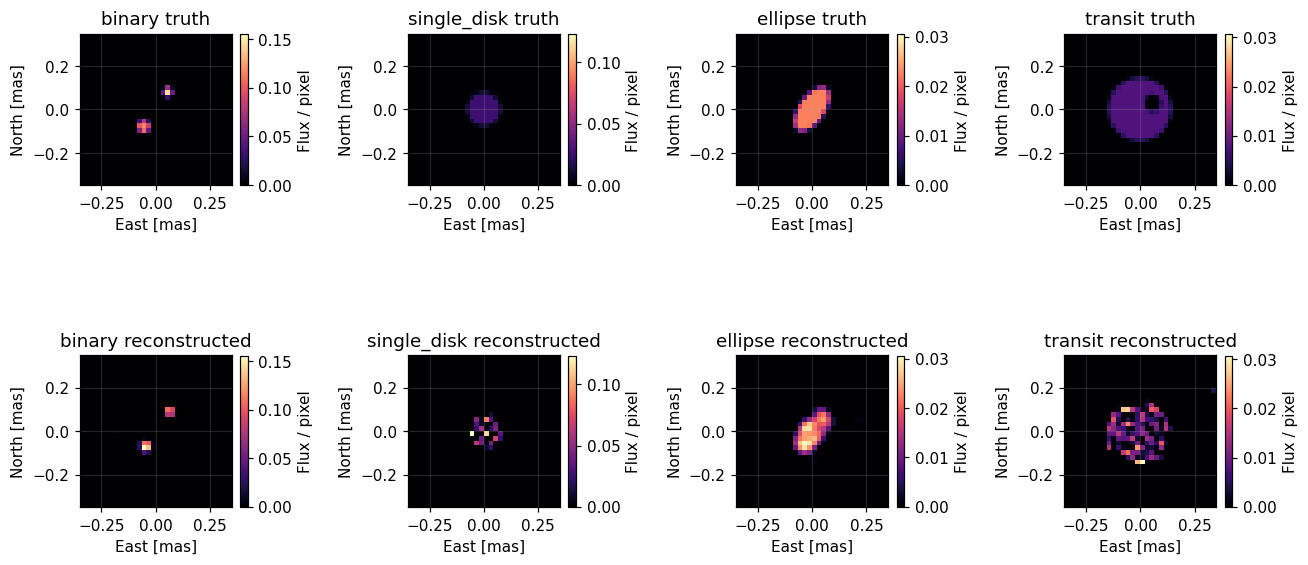

In [10]:
def truth_image(case,source,theta):
    # 子像素面积平均仅用于拟合后的真图评价；不作为重建器输入。
    step=theta[1]-theta[0]
    offsets=(np.arange(8)+.5)/8-.5
    high=(theta[:,None]+offsets*step).ravel()
    y,x=np.meshgrid(high,high,indexing='ij')
    if case in ('binary','single_disk'):
        pa=np.deg2rad(source.position_angle_deg)
        dx=.5*source.separation_mas*np.sin(pa) if case=='binary' else 0.
        dy=.5*source.separation_mas*np.cos(pa) if case=='binary' else 0.
        image=(((x+dx)**2+(y+dy)**2)<=(source.primary_diameter_mas/2)**2).astype(float)
        image/=image.sum()
        if case=='binary':
            secondary=(((x-dx)**2+(y-dy)**2)<=(source.secondary_diameter_mas/2)**2).astype(float)
            image+=source.flux_ratio_secondary_to_primary*secondary/secondary.sum()
    elif case=='ellipse':
        pa=np.deg2rad(source.position_angle_deg)
        major=x*np.sin(pa)+y*np.cos(pa);minor=x*np.cos(pa)-y*np.sin(pa)
        image=((major/(source.major_diameter_mas/2))**2+(minor/(source.minor_diameter_mas/2))**2<=1).astype(float)
    else:
        image=(x*x+y*y<=(source.stellar_diameter_mas/2)**2).astype(float)
        image[((x-source.planet_east_offset_mas)**2+(y-source.planet_north_offset_mas)**2)<=(source.planet_diameter_mas/2)**2]=0
    image=image.reshape(len(theta),8,len(theta),8).mean(axis=(1,3))
    return image/image.sum()

truths={}; alignment_rows=[]
fig,axes=plt.subplots(2,4,figsize=(12,6))
for column,(case,source) in enumerate(source_cases.items()):
    fit=fits[case];truth=truth_image(case,source,fit.theta_mas);truths[case]=truth
    aligned,metrics=reco._best_truth_alignment(fit.image,truth)
    alignment_rows.append({'source':case,**{k:v for k,v in metrics.items() if np.isscalar(v)}})
    for row,image in enumerate([truth,aligned]):
        im=axes[row,column].imshow(image,origin='lower',extent=[-.35,.35,-.35,.35],cmap='magma',
                                  vmin=0,vmax=max(truth.max(),aligned.max()))
        axes[row,column].set(xlabel='East [mas]',ylabel='North [mas]',title=case+(' truth' if row==0 else ' reconstructed'))
        fig.colorbar(im,ax=axes[row,column],fraction=.045,label='Flux / pixel')
fig.tight_layout();fig.savefig(FIG/'05_reconstruction.png');plt.show()
pd.DataFrame(alignment_rows).to_csv(OUT/'image_alignment.csv',index=False)
summary['image_alignment']=alignment_rows

## 8. 网格、UV合并与随机实现的稳定性

网格/合并对照保留同一批测量，避免把噪声变化误认为分辨率改善。
重复实现使用独立的统计噪声和共同标定增益，给出图像误差分布与像素离散度。
这些图像离散度是有限次数的稳定性诊断，不是逐像素95%置信区间。


In [11]:
convergence_rows=[]
for size,cell in [(24,120.),(40,120.),(32,60.)]:
    case='binary';uv=sii.prepare_reconstruction_uv(pipelines[case].measurements,cell_mlambda=cell)
    kernel=reco.power_sampling_kernel(uv,size,FOV)
    fit=reco.reconstruct_uv_data(uv,grid_size=size,fov_mas=FOV,support_radius_mas=.32,
        starts=3,max_iter=8000,smoothness=fits[case].metrics['smoothness'],seed=SEED+500,_power_kernel=kernel)
    truth=truth_image(case,source_cases[case],fit.theta_mas)
    _,metrics=reco._best_truth_alignment(fit.image,truth)
    convergence_rows.append({'grid':size,'cell_Mlambda':cell,'constraints':len(uv.u_lambda),
        'converged':fit.metrics['optimizer_success'],'truth_nrmse':metrics['truth_nrmse'],
        'truth_correlation':metrics['truth_correlation'],'power_rmse':fit.metrics['fit_rmse']})
convergence_table=pd.DataFrame(convergence_rows)
convergence_table.to_csv(OUT/'convergence.csv',index=False)
summary['convergence']=convergence_table.to_dict(orient='records')
display(convergence_table)

,grid,cell_Mlambda,constraints,converged,truth_nrmse,truth_correlation,power_rmse
0,24,120.0,1023,True,0.498488,0.900082,0.042283
1,40,120.0,1023,True,0.325038,0.949312,0.041857
2,32,60.0,3013,True,0.686869,0.781924,0.058650


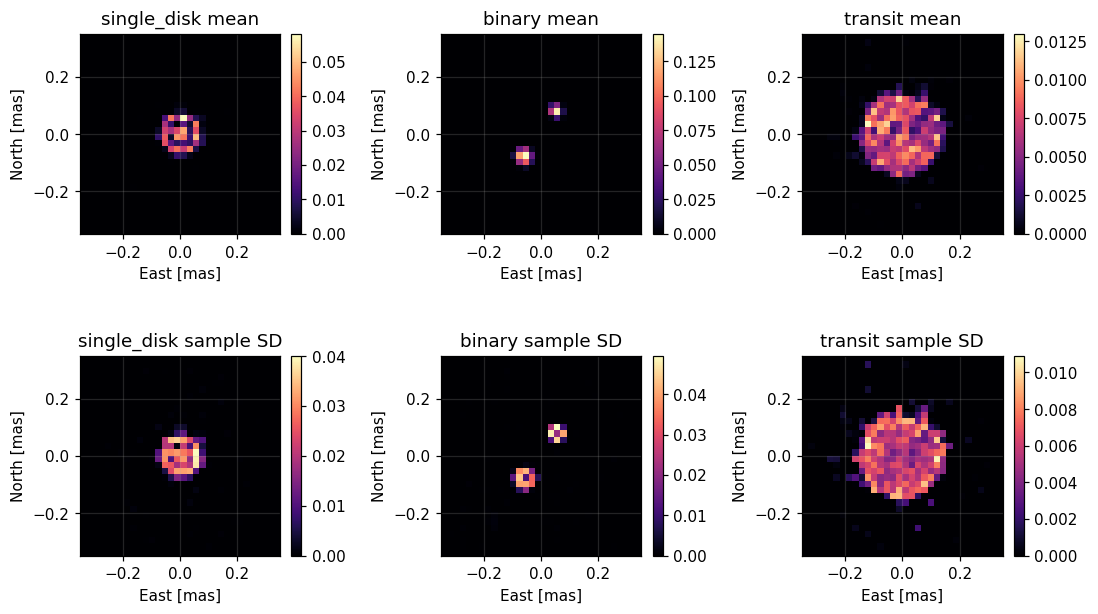

,source,nrmse_mean,nrmse_std,converged_fraction
0,binary,0.554330,0.050646,1.000000
1,single_disk,1.195068,0.070676,0.916667
2,transit,0.965235,0.094012,1.000000


In [12]:
repeat_rows=[]; ensembles={}; REPEATS=12
for source_index,case in enumerate(['single_disk','binary','transit']):
    uv=uv_data[case];kernel=kernels[case]
    reference=pipelines[case].measurements.copy()
    # 用同一加权分组规则形成理论期望，只用于生成检验样本。
    reference['visibility2_measured']=reference.visibility2_true
    model=sii.prepare_reconstruction_uv(reference,cell_mlambda=120.).visibility_abs2
    images=[]
    for repeat in range(REPEATS):
        rng=np.random.default_rng(SEED+1000+100*source_index+repeat)
        gain=1+rng.normal(0.,uv.calibration_relative_sigma)
        trial=replace(uv,visibility_abs2=gain*model+rng.normal(0.,uv.sigma))
        fit=reco.reconstruct_uv_data(trial,grid_size=GRID,fov_mas=FOV,support_radius_mas=.32,
            starts=2,max_iter=8000,smoothness=fits[case].metrics['smoothness'],
            seed=SEED+2000+repeat,_power_kernel=kernel)
        aligned,metrics=reco._best_truth_alignment(fit.image,truths[case]);images.append(aligned)
        repeat_rows.append({'source':case,'repeat':repeat,'converged':fit.metrics['optimizer_success'],
            'stationarity_passed':fit.metrics['stationarity_passed'],
            'nrmse':metrics['truth_nrmse'],'truth_correlation':metrics['truth_correlation'],
            'retained_flux':metrics['truth_alignment_retained_flux']})
    ensembles[case]=np.asarray(images)
repeat_table=pd.DataFrame(repeat_rows);repeat_table.to_csv(OUT/'image_repeats.csv',index=False)
summary['image_repeats']=repeat_table.groupby('source').agg(
    nrmse_mean=('nrmse','mean'),nrmse_std=('nrmse','std'),converged_fraction=('converged','mean')).reset_index().to_dict(orient='records')
fig,axes=plt.subplots(2,3,figsize=(10,6))
for column,(case,images) in enumerate(ensembles.items()):
    for row,image in enumerate([images.mean(axis=0),images.std(axis=0,ddof=1)]):
        im=axes[row,column].imshow(image,origin='lower',extent=[-.35,.35,-.35,.35],cmap='magma')
        axes[row,column].set(title=case+(' mean' if row==0 else ' sample SD'),xlabel='East [mas]',ylabel='North [mas]')
        fig.colorbar(im,ax=axes[row,column],fraction=.045)
fig.tight_layout();fig.savefig(FIG/'06_image_stability.png');plt.show()
display(pd.DataFrame(summary['image_repeats']))

## 9. 哪些结论已验证，哪些结论不能从本Notebook推出

该工作流检验了参数来源、相关关系、线性响应、协方差、共同标定误差、光谱/时间平均和重建稳定性。
它仍采用弱热光近似、静态天体和固定透过率场景；未知电子学项关闭。
12次图像重复不足以声称极小的伪结构概率，不能将两峰诊断或图像相似度当作行星检出显著性。
下面保留所有检验数值，未收敛或不闭合的条目不会被删除。


In [13]:
summary['scope']={'source':'static scenes, observed total AB magnitude',
    'optical_passband':'2 nm top-hat scenario over main response curves',
    'source_transmission_scale':.7836336,'source_transmission_origin':'scenario assumption, not measured electronics',
    'weak_thermal_approximation':'pair generator omits thermal self noise; degeneracy is reported',
    'reconstruction_repeats':REPEATS,'pixel_intervals':'not confidence intervals',
    'calibration':'shared gain profiled, independent statistical sigma retained',
    'joint_observation':'fresh short and longer raw records executed; hour-scale inference remains separate',
    'notebook_execution':'all cells executed in this run'}
(OUT/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
print('科学验证结果已写入：',OUT/'summary.json')
display(pd.DataFrame(summary['reconstruction']))

科学验证结果已写入： E:\LACT_pylast2\sii_gls_review_20260905\validation\sii_science\summary.json


,source,constraints,converged,chi2_per_point,gain,gain_sigma,smoothness,stationarity_gap,stationarity_passed,iterations,training_all_converged
0,binary,1023,True,0.956188,1.020011,0.001869,0.0001,0.010992,True,1542,True
1,single_disk,1023,True,0.982296,1.010789,0.002565,0.0000,0.034678,True,5871,True
2,ellipse,1023,True,1.033671,1.011268,0.002746,0.0100,0.019325,True,889,True
3,transit,1023,True,0.897442,1.009222,0.004344,0.0001,0.010076,True,1475,True
